In [1]:
import cv2
import os
import matplotlib.pyplot as plt
import numpy as np

import urllib.request

from IPython.display import display, Image


In [2]:
# If the folder "resources" exists, do nothing, else create the folder "resources"

resources_folder = "resources"

if os.path.isdir(resources_folder):
    print(f"Directory: `{resources_folder}` already exists")
else:
    print(f"Creating directory: `{resources_folder}`")
    os.makedirs(resources_folder)
    

Directory: `resources` already exists


In [3]:
# iruma_army_url = "https://github.com/cookieSensei/AI-tutorials/blob/main/iruma%20kun.PNG?raw=true"

# Creating CLI path to the image
iruma_army_img_path = os.path.join("resources", "iruma kun.PNG")
iruma_army_img_path

'resources/iruma kun.PNG'

In [4]:
def cv2_imshow(img_arr):
    """Function to visualize an image loaded using opencv.
    
    Parameters:
        img_arr: image array ing BGR format or say image loaded using opencv
    """
    
    img_arr = img_arr.copy()    
    image_rgb = cv2.cvtColor(img_arr, cv2.COLOR_BGR2RGB) 

    plt.figure(figsize=(6,6))
    plt.imshow(image_rgb)
    plt.show()

# Kernel and Blur

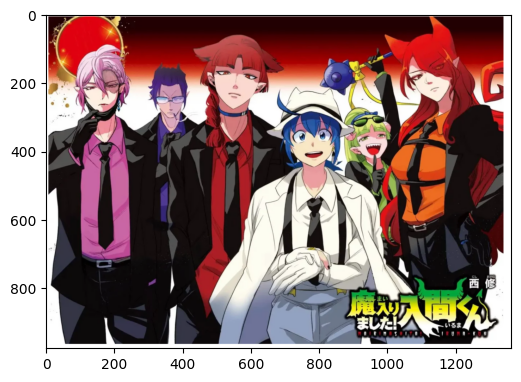

In [5]:
img = cv2.imread(iruma_army_img_path)
cv2_imshow(img)

In [6]:
sample_kernel = np.ones((9,9), np.float32)/81
sample_kernel

array([[0.01234568, 0.01234568, 0.01234568, 0.01234568, 0.01234568,
        0.01234568, 0.01234568, 0.01234568, 0.01234568],
       [0.01234568, 0.01234568, 0.01234568, 0.01234568, 0.01234568,
        0.01234568, 0.01234568, 0.01234568, 0.01234568],
       [0.01234568, 0.01234568, 0.01234568, 0.01234568, 0.01234568,
        0.01234568, 0.01234568, 0.01234568, 0.01234568],
       [0.01234568, 0.01234568, 0.01234568, 0.01234568, 0.01234568,
        0.01234568, 0.01234568, 0.01234568, 0.01234568],
       [0.01234568, 0.01234568, 0.01234568, 0.01234568, 0.01234568,
        0.01234568, 0.01234568, 0.01234568, 0.01234568],
       [0.01234568, 0.01234568, 0.01234568, 0.01234568, 0.01234568,
        0.01234568, 0.01234568, 0.01234568, 0.01234568],
       [0.01234568, 0.01234568, 0.01234568, 0.01234568, 0.01234568,
        0.01234568, 0.01234568, 0.01234568, 0.01234568],
       [0.01234568, 0.01234568, 0.01234568, 0.01234568, 0.01234568,
        0.01234568, 0.01234568, 0.01234568, 0.01234568],


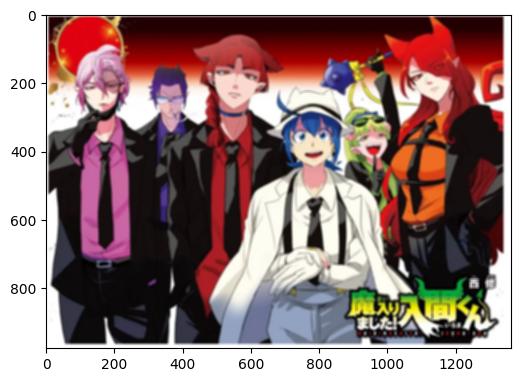

In [7]:
img1 = cv2.filter2D(src=img, ddepth=-1, kernel=sample_kernel)
cv2_imshow(img1)

## Gaussian blur

In [8]:
img.shape

(977, 1363, 3)

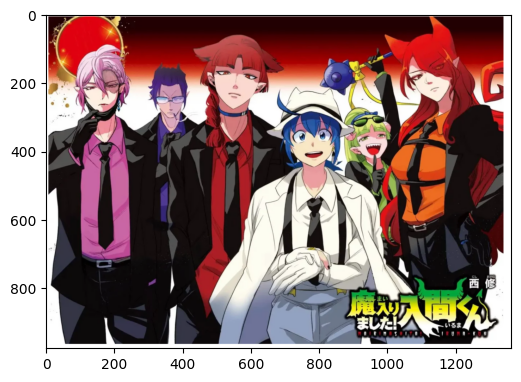

In [9]:
cv2_imshow(img)

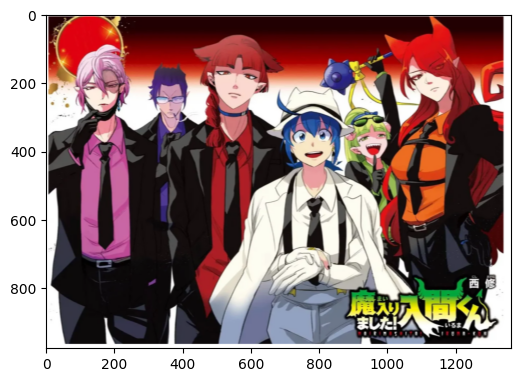

In [10]:
gaussian_blur = cv2.GaussianBlur(src=img, ksize=(5,5),
                                 sigmaX=5,
                                 sigmaY=0.1)
cv2_imshow(gaussian_blur)

## Vertical gaussian blur

In [11]:
img = cv2.imread(iruma_army_img_path)
img.shape

(977, 1363, 3)

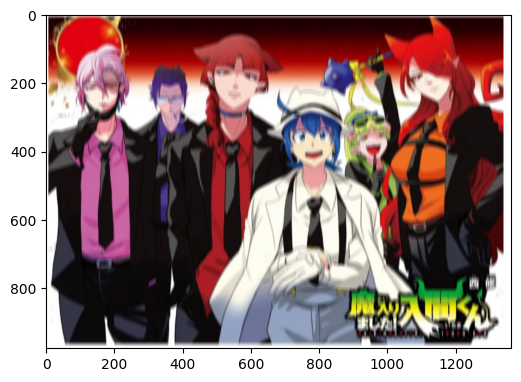

In [12]:
# Vertical blur
gaussian_blur4 = cv2.GaussianBlur(src=img, ksize=(15,15),
                                 sigmaX=0.1,
                                 sigmaY=20)
cv2_imshow(gaussian_blur4)

## Median Blur

Each pixel in the source image is replaced by the median value# of the image pixels in the kernel area

In [13]:
img = cv2.imread(iruma_army_img_path)
img.shape

(977, 1363, 3)

In [14]:
img_med_blur = cv2.medianBlur(src=img, ksize=11)
img_med_blur_rgb = cv2.cvtColor(img_med_blur, cv2.COLOR_BGR2RGB)
img_med_blur_rgb.shape

(977, 1363, 3)

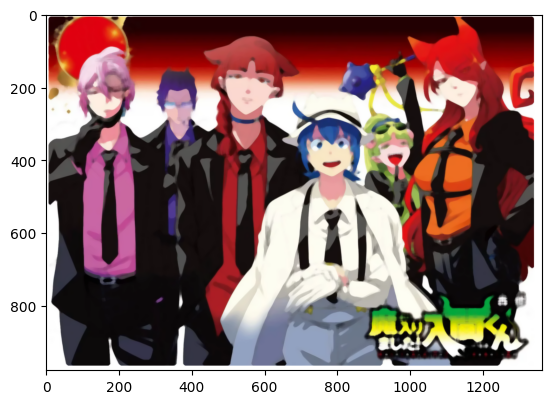

In [15]:
plt.imshow(img_med_blur_rgb)

## Bilateral Filtering

While blurring can be an effective way to reduce noise in an image, it is often not desirable to blur the entire image, as important details and sharp edges may be lost. In such cases, bilateral filtering can make your life easier.

In [16]:
img = cv2.imread(iruma_army_img_path)
img.shape

(977, 1363, 3)

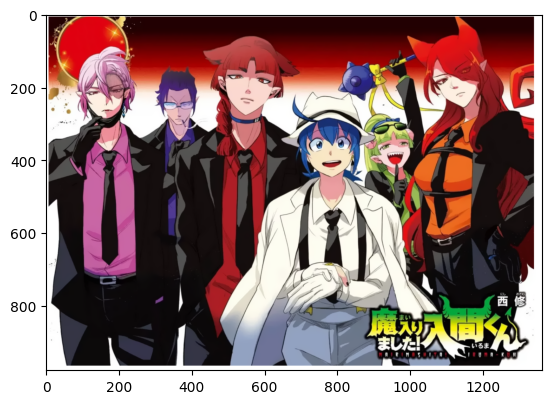

In [17]:
bilateral_filtering = cv2.bilateralFilter(src=img,
                                          d=20,
                                          sigmaColor=10,
                                          sigmaSpace=10)

bilateral_filtering_rgb = cv2.cvtColor(bilateral_filtering, cv2.COLOR_BGR2RGB)
plt.imshow(bilateral_filtering_rgb)


# Image array normalization

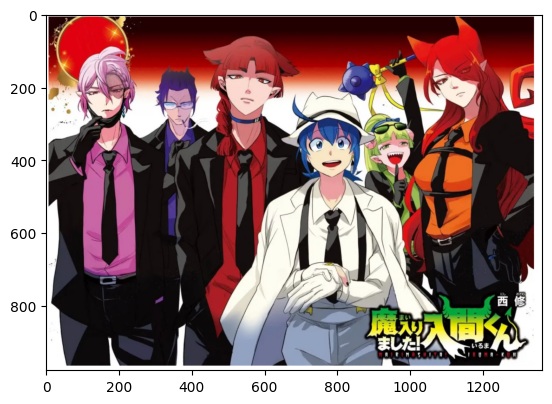

In [18]:
image_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(image_rgb)

In [19]:
standardized_image_rgb = image_rgb/255.0
standardized_image_rgb.shape

(977, 1363, 3)

In [20]:
# Standardized or normlized image would mean that
# the maximum value of pixel brightness is 1 instead of 255
# We take the whole range of brightness from 0-255 and
# just normalize it into 0-1 by dividing each pixel numeric by 255
standardized_image_rgb[0, 0]

array([1., 1., 1.])

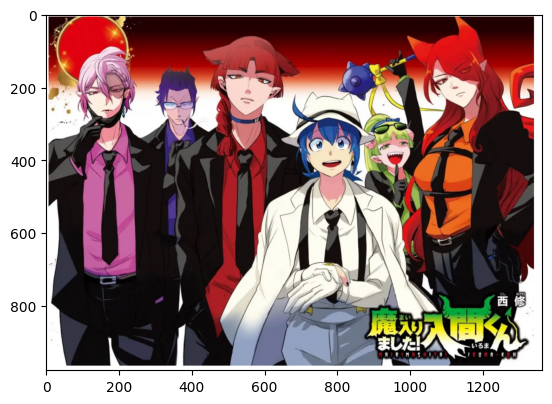

In [21]:
plt.imshow(standardized_image_rgb)

In [22]:
np.min(standardized_image_rgb)

0.0

In [23]:
np.max(standardized_image_rgb)

1.0

In [24]:
np.max(image_rgb)

255

# Thresholding

In [25]:
resources_folder

'resources'

In [26]:
img_dark_nlp_tfidf = os.path.join(resources_folder, "dark_nlp_tfidf.jpg")
img_dark_nlp_tfidf

'resources/dark_nlp_tfidf.jpg'

In [27]:
img_nlp = cv2.imread(img_dark_nlp_tfidf)
img_nlp.shape

(4032, 2268, 3)

In [28]:
img_nlp_rgb = cv2.cvtColor(img_nlp, cv2.COLOR_BGR2RGB)
img_nlp_rgb.shape

(4032, 2268, 3)

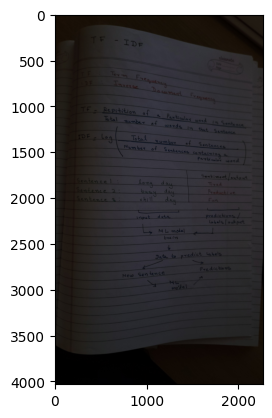

In [29]:
plt.imshow(img_nlp_rgb)

In [30]:
height, width, _ = img_nlp_rgb.shape

In [31]:
# Downsizing the image to 50% of its width and 40% of its height
img = cv2.resize(img_nlp_rgb, (int(width*0.5), int(height*0.4)),
                 interpolation=cv2.INTER_LINEAR)

img.shape

(1612, 1134, 3)

### Capture pixel values from a given range


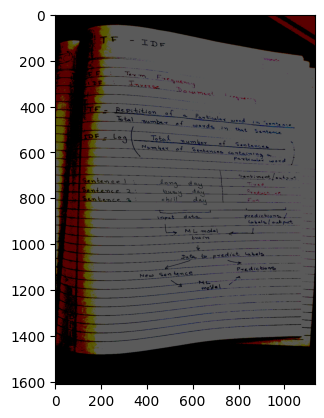

In [32]:
retval, threshold = cv2.threshold(img, 30, 90, cv2.THRESH_BINARY)
plt.imshow(threshold)

#### Very Dark Image threshold

1. Load image
2. Blur a little to reduce noise
3. Grayscale
4. Threshold

In [33]:
img_nlp = cv2.imread(img_dark_nlp_tfidf)
img_nlp.shape

(4032, 2268, 3)

In [34]:
img_nlp_rgb = cv2.cvtColor(img_nlp, cv2.COLOR_BGR2RGB)
img_nlp_rgb.shape

(4032, 2268, 3)

In [35]:
img_nlp_rgb_blur = cv2.GaussianBlur(img_nlp_rgb, (5,5), 0)
img_nlp_rgb_blur.shape

(4032, 2268, 3)

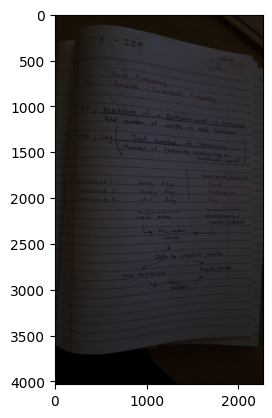

In [36]:
plt.imshow(img_nlp_rgb_blur, cmap="gray")

In [37]:
gray = cv2.cvtColor(img_nlp_rgb_blur, cv2.COLOR_RGB2GRAY)
gray.shape

(4032, 2268)

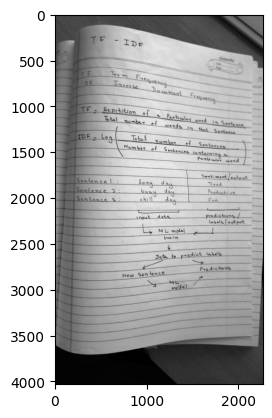

In [38]:
# We need to tell matplotlib here, that the image is 
# only two dimensional, row and column pixel
plt.imshow(gray, cmap="gray")

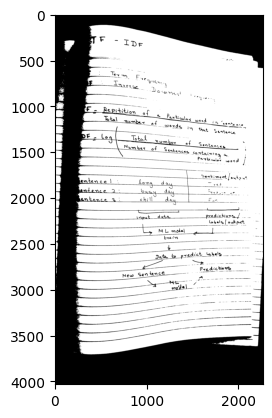

In [39]:
retval2, threshold2 = cv2.threshold(gray, 30, 90,  cv2.THRESH_BINARY)
plt.imshow(threshold2, cmap="gray")

### Adaptive threshold

In [40]:
gaussian = cv2.adaptiveThreshold(gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 61, 5)
gaussian.shape

(4032, 2268)

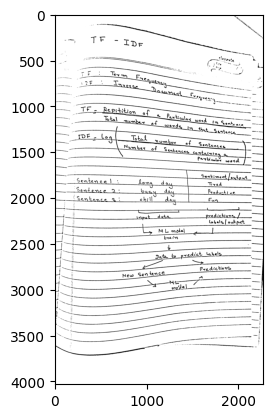

In [41]:
plt.imshow(gaussian, cmap="gray")

## Bright Image Threshold

1. Load image
2. Blur a little to reduce noise
3. Grayscale
4. Threshold

In [42]:
bright_img_path = os.path.join(resources_folder, "bright_nlp_ifidf.jpg")
bright_img_path

'resources/bright_nlp_ifidf.jpg'

In [43]:
img_bright_nlp = cv2.imread(bright_img_path)
img_bright_nlp.shape

(4032, 2268, 3)

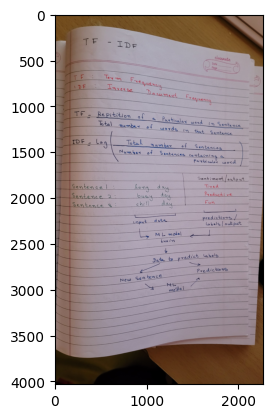

In [44]:
img_bright_nlp_rgb = cv2.cvtColor(img_bright_nlp, cv2.COLOR_BGR2RGB)
plt.imshow(img_bright_nlp_rgb)
plt.show()

In [45]:
img_bright_nlp_rgb_blur = cv2.GaussianBlur(img_bright_nlp_rgb, (5,5), 0)
img_bright_nlp_rgb_blur.shape

(4032, 2268, 3)

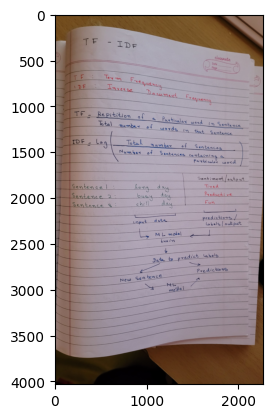

In [46]:
plt.imshow(img_bright_nlp_rgb_blur)

In [47]:
gray2 = cv2.cvtColor(img_bright_nlp_rgb_blur, cv2.COLOR_RGB2GRAY)
gray2.shape

(4032, 2268)

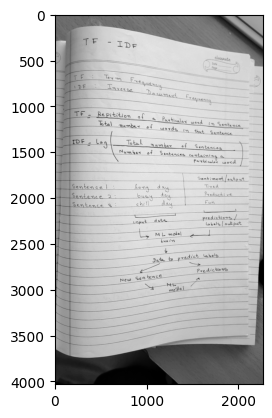

In [48]:
plt.imshow(gray2, cmap="gray")

In [49]:
gaussian2 = cv2.adaptiveThreshold(gray2, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 61, 5)
gaussian2.shape

(4032, 2268)

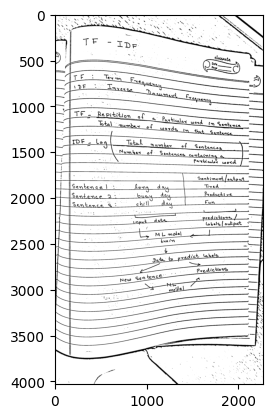

In [50]:
plt.imshow(gaussian2, cmap="gray")
plt.show()